# DDS2M — Experimental run: SVD vs DDS2M (no GT)

Single experimental bCARS cube `preprocessed_nofilter_111825_male-phe(ctrl)_ABR14(WT)_02` —
**no ground truth**. Goal: eyeball the DDS2M reconstruction against the SVD baseline, then
carry both through the same Hilbert + PEC Raman retrieval. Everything lives in the
**dispersive, normalized [0, 1]** domain (the `y_0_real` / `x_best` keys). Loading and
plotting reuse the shared `svd-bench` helpers (`scripts.viz`, `scripts.postprocess`) from the
S2DIP repo, so SVD and DDS2M are scored identically.

> **Kernel:** run this notebook with the `crikit3` conda env (it has `crikit` + the S2DIP
> `svd-bench` helpers). The DDS2M `y_0` is verified to equal `y_0_real`, so the SVD baseline
> and DDS2M denoise the exact same noisy cube.

In [57]:
import os, glob, sys
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# reuse the shared S2DIP svd-bench helpers (viz + postprocess) and crikit's SVD
S2DIP_DIR = "/mnt/d/GaTech Dropbox/Haoyu Xu/workspace/crikit3_denoise/S2DIP"
sys.path.insert(0, os.path.join(S2DIP_DIR, "svd-bench"))
import scripts.viz as viz
from scripts.postprocess import load_mat_inputs, PostprocessConfig, run_pipeline

# ── config ─────────────────────────────────────────────────
# DDS2M reconstruction for this experimental cube (no ground truth)
RESULTS_DIR = ("results/denoising0.07_preprocessed_nofilter_glycerol_4Xdiluted_20251111_PAD128_rank_10_eta_1_beta_0.0001-0.005-linear_iteration_1000-2000_1-1_beta_0_lr_0.0005")
               #"_rank_10_eta_1_beta_0.0001-0.005-linear_iteration_1000-2000_1-1_beta_0_lr_0.0005")
# source .mat that holds y_0_real / norm_* AND the wavenumber axis `wn`
MAT_PATH = ("/mnt/d/GaTech Dropbox/Haoyu Xu/workspace/crikit3_denoise/2025_Celegans/data/"
            "20251111/preprocessed_vst_nomedian/mat_whittaker_p0.05/"
            "preprocessed_nofilter_glycerol_4Xdiluted_20251111.mat")

SVS_INDICES = list(range(5))   # singular-value indices kept by the SVD baseline
VIZ_WN      = 1650.0           # wavenumber (cm^-1) for the spatial imshow
VIZ_PIXEL   = (50, 50)        # (y, x) pixel for the spectral plots
SPEC_XLIM   = None             # spectral-plot x-limits (cm^-1); None -> full clipped range
# ─────────────────────────────────────────────────────

## 1  Load real inputs (no ground truth)

`load_mat_inputs` returns the noisy cube normalized to `[0, 1]` plus the physical de-normalizers.
`img_clean` is not a real GT here (experimental data) and is ignored. The wavenumber axis is
baked into the same `.mat`.

In [58]:
d = load_mat_inputs(MAT_PATH)
Z_noisy    = d["y_0_real"].astype(np.float32)          # (ny,nx,nfp) noisy, normalized [0,1]
nmin, nmax = d["norm_min"], d["norm_max"]              # physical-scale de-normalizers
wn = np.ravel(sio.loadmat(MAT_PATH)["wn"]).astype(np.float64)
assert wn.shape[0] == Z_noisy.shape[-1], (wn.shape, Z_noisy.shape)

band = viz.nearest_band(wn, VIZ_WN)
spec_xlim = SPEC_XLIM if SPEC_XLIM is not None else (float(wn.min()), float(wn.max()))

print("Z_noisy ", Z_noisy.shape, "range [%.3f, %.3f]" % (Z_noisy.min(), Z_noisy.max()))
print("wn      ", wn.shape, "range [%.1f, %.1f] cm^-1" % (wn.min(), wn.max()))
print("norm_min/max  %.5f / %.5f" % (nmin, nmax))
print("VIZ_WN %.0f -> band %d (%.1f cm^-1)" % (VIZ_WN, band, wn[band]))

Z_noisy  (64, 64, 685) range [0.000, 1.000]
wn       (685,) range [400.6, 1797.9] cm^-1
norm_min/max  -6.97714 / 6.97714
VIZ_WN 1650 -> band 618 (1650.6 cm^-1)


## 2  SVD baseline (crikit `SVDDecompose` + manual singular-value selection)

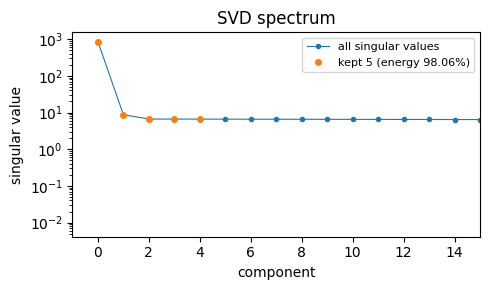

[ok] SVD (64, 64, 685) range [0.054, 0.916]


In [59]:
from crikit.preprocess.denoise import SVDDecompose

methods = {}   # name -> dispersive cube, normalized [0,1]

U, s, Vh = SVDDecompose().calculate(Z_noisy)
svs = np.asarray(SVS_INDICES)                                  # selected singular-value indices
energy = np.sum(s[svs] ** 2) / np.sum(s ** 2) * 100

plt.figure(figsize=(5, 3))
plt.plot(s, ".-", lw=0.8, label="all singular values")
plt.plot(svs, s[svs], "o", ms=4, label="kept %d (energy %.2f%%)" % (len(svs), energy))
plt.yscale("log"); plt.xlabel("component"); plt.ylabel("singular value")
plt.xlim(-1, len(svs) + 10)
plt.title("SVD spectrum"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

reconstructed = np.dot(U[:, svs], s[svs, None] * Vh[svs, :]).reshape(Z_noisy.shape)
methods["SVD"] = reconstructed.astype(np.float32)
print("[ok] SVD %s range [%.3f, %.3f]" % (methods["SVD"].shape, methods["SVD"].min(), methods["SVD"].max()))

## 3  Load the DDS2M reconstruction

DDS2M stores `x_best` (reconstruction at best proxy-PSNR step) and `x_recon` (final step), plus
the `y_0` it denoised. We assert `y_0 == y_0_real` so SVD and DDS2M share the exact same noisy
input. Both cubes are already in the normalized `[0, 1]` dispersive domain.

In [60]:
res = sio.loadmat(sorted(glob.glob(os.path.join(RESULTS_DIR, "x_*.mat")))[-1])
assert np.allclose(np.float32(res["y_0"]), Z_noisy, atol=1e-3), "DDS2M y_0 != y_0_real"

dds = {
    "DDS2M best":  np.clip(np.float32(res["x_best"]),  0, 1),
    "DDS2M final": np.clip(np.float32(res["x_recon"]), 0, 1),
}
print("DDS2M proxy PSNR  final %.2f dB | best %.2f dB"
      % (float(res["psnr"].flat[0]), float(res["psnr_best"].flat[0])))
for k, v in dds.items():
    print("  %-12s %s range [%.3f, %.3f]" % (k, v.shape, v.min(), v.max()))

DDS2M proxy PSNR  final 6.27 dB | best 6.59 dB
  DDS2M best   (64, 64, 685) range [0.034, 0.858]
  DDS2M final  (64, 64, 685) range [0.071, 0.869]


## 4  Spatial comparison — Noisy vs SVD vs DDS2M

One panel per method at `VIZ_WN`, shared robust color scale. Compare how well DDS2M suppresses
speckle while keeping structure sharp, relative to the SVD baseline.

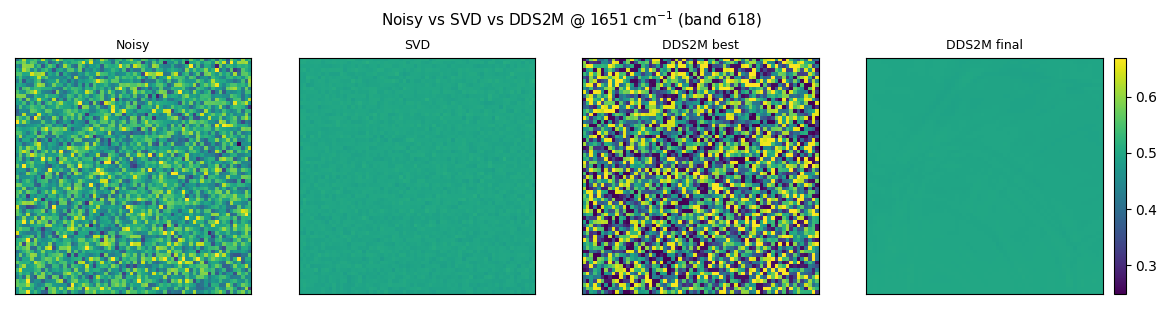

In [61]:
combined = {"Noisy": Z_noisy, **methods, **dds}   # Noisy, SVD, DDS2M best/final
fig = viz.imshow_methods_at_band(
    combined, band, wn=wn, ncols=4, cmap="viridis", share_clim=True,
    title="Noisy vs SVD vs DDS2M @ %.0f cm$^{-1}$ (band %d)" % (wn[band], band))
plt.show()

## 5  Spectral comparison — SVD vs DDS2M

Each method's spectrum at `VIZ_PIXEL`, with the **noisy** spectrum drawn bold black. DDS2M
should flatten the noise while still tracking the real Raman peaks; SVD is the reference.

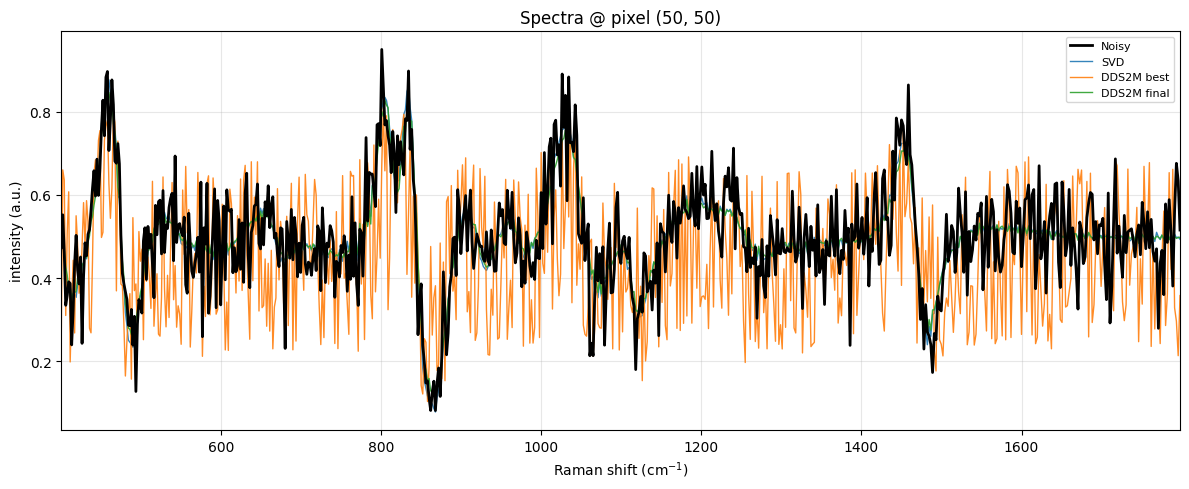

In [62]:
overlay = {**methods, **dds}      # SVD + DDS2M; Noisy drawn as bold-black reference
fig, ax = viz.plot_methods_at_pixel(
    overlay, VIZ_PIXEL, wn=wn, gt=Z_noisy, gt_label="Noisy",
    xlim=spec_xlim, figsize=(12, 5))
plt.show()

## 6  Focused side-by-side — SVD vs DDS2M

Pick which DDS2M reconstruction (`best` or `final`) to carry forward and view it next to SVD as
both a band image and a pixel spectrum.

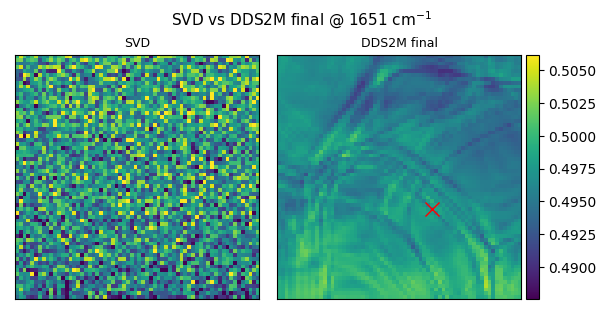

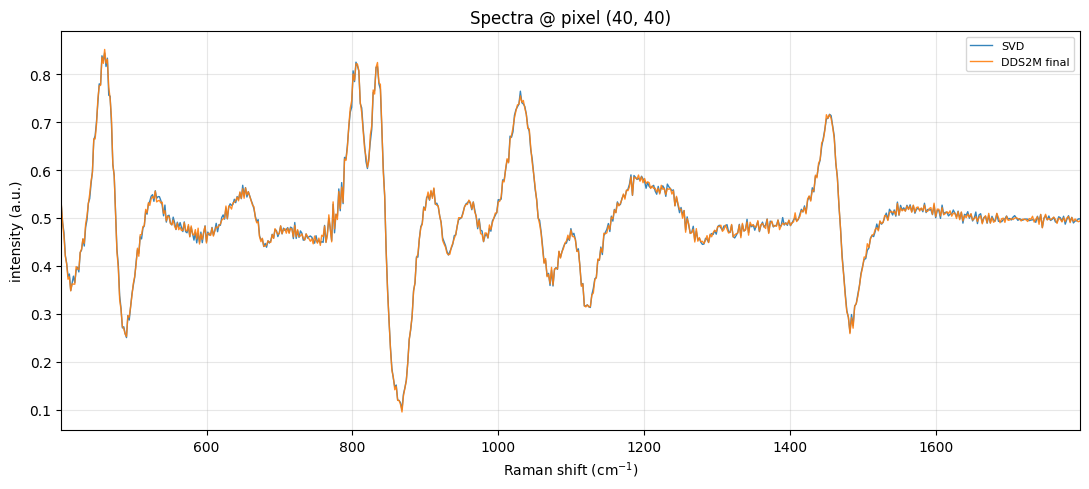

In [64]:
DDS_PICK  = "DDS2M final"   # ← "DDS2M best" or "DDS2M final"
VIZ_PIXEL = (40, 40)     # (y, x) pixel for the spectral plot

trio = {"SVD": methods["SVD"], DDS_PICK: dds[DDS_PICK]}
viz.imshow_methods_at_band(trio, band, wn=wn, ncols=len(trio), share_clim=True,
                           title="SVD vs %s @ %.0f cm$^{-1}$" % (DDS_PICK, wn[band]))
plt.plot(VIZ_PIXEL[1], VIZ_PIXEL[0], "rx", ms=10, label="pixel for spectral plot")
plt.show()

viz.plot_methods_at_pixel(trio, VIZ_PIXEL, wn=wn, xlim=spec_xlim)
plt.show()

## 8  KK / PEC Raman — SVD vs DDS2M

Run the same Hilbert phase retrieval + PEC baseline correction on the SVD-denoised and the
chosen DDS2M cube. `run_pipeline(phase_method="hilbert")` forms the analytic signal; the `+C`
offset keeps the phase non-winding so PEC is well-posed.

In [65]:
# ── Same Hilbert+PEC op on SVD-denoised AND the chosen DDS2M cube ──
to_phys = lambda c: c * (nmax - nmin) + nmin          # normalized [0,1] -> physical dispersive Re(chi)

PP_CFG = PostprocessConfig(
    phase_method="hilbert", hilbert_pad_factor=2, hilbert_n_edge=30,      # Hilbert params
    phase_err_correct=True,
    pec_kwargs=dict(smoothness_param=10, asym_param=3e-4, redux=5, order=2,
                    rng=None, fix_end_points=False, fix_rng=None, fix_const=1,
                    max_iter=100, min_diff=1e-6, verbose=False),          # PEC params
    scale_err_correct=False,
)

def post_raman(cube01):
    x = to_phys(np.ascontiguousarray(cube01, np.float32))
    C = float(np.abs(x).max())                        # +C offset -> PEC-compatible (non-winding phase)
    return run_pipeline(x + C, PP_CFG).raman          # np.imag(ph) after PEC

DDS_PICK = "DDS2M final"
post = {"SVD": post_raman(methods["SVD"]),
        DDS_PICK: post_raman(dds[DDS_PICK])}
for name, r in post.items():
    print("[raman] %-12s %s  range [%.3f, %.3f]" % (name, r.shape, r.min(), r.max()))

[raman] SVD          (64, 64, 685)  range [-0.986, 13.296]
[raman] DDS2M final  (64, 64, 685)  range [-0.393, 11.478]


/home/hxu256/miniconda3/envs/crikit3/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


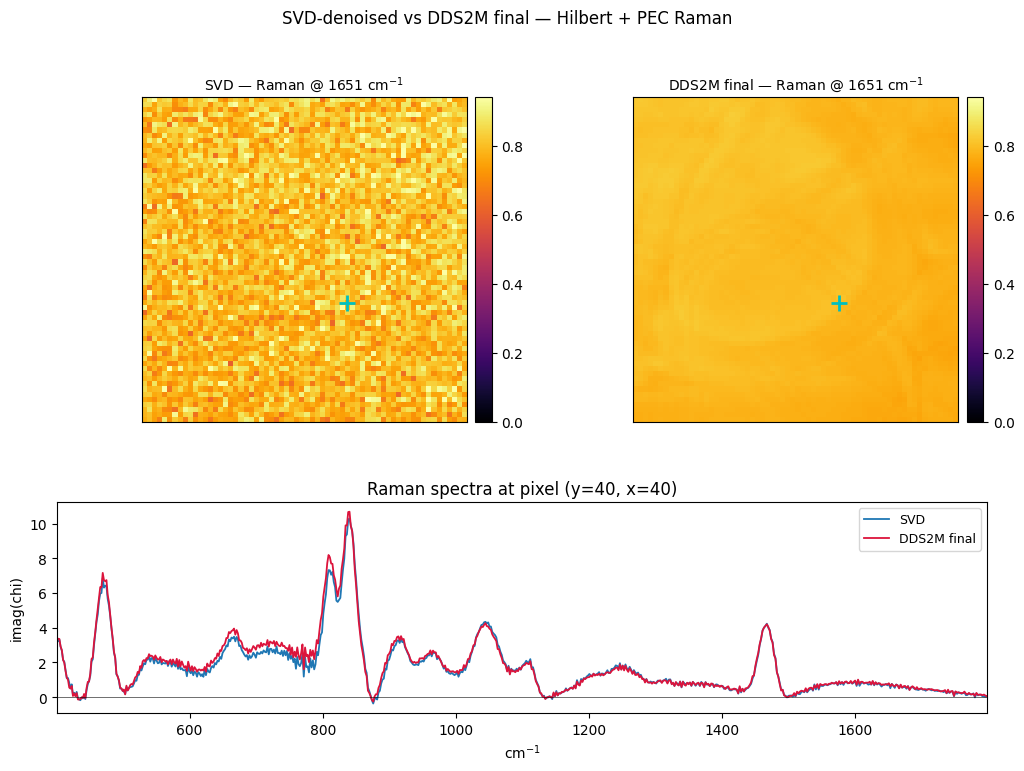

In [66]:
# ── SVD-denoised vs DDS2M Raman: band images side by side, spectra underneath ──
labels = list(post)                                   # ["SVD", "DDS2M best"]
imgs   = [post[k][:, :, band] for k in labels]
vmax   = float(np.percentile(np.concatenate([im.ravel() for im in imgs]), 99))
py, px = VIZ_PIXEL

fig = plt.figure(figsize=(12, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.3], hspace=0.30, wspace=0.12)
for j, (lab, im) in enumerate(zip(labels, imgs)):
    ax = fig.add_subplot(gs[0, j])
    h  = ax.imshow(im, cmap="inferno", vmin=0, vmax=vmax)
    ax.plot(px, py, "c+", ms=12, mew=2)               # spectral-plot pixel
    ax.set_title("%s — Raman @ %.0f cm$^{-1}$" % (lab, wn[band]), fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(h, ax=ax, fraction=0.046, pad=0.02)

axs = fig.add_subplot(gs[1, :])
for lab, c in zip(labels, ("tab:blue", "crimson")):
    axs.plot(wn, post[lab][py, px], lw=1.3, color=c, label=lab)
axs.axhline(0, color="k", lw=0.4); axs.set_xlim(spec_xlim)
axs.set_xlabel("cm$^{-1}$"); axs.set_ylabel("imag(chi)")
axs.set_title("Raman spectra at pixel (y=%d, x=%d)" % (py, px)); axs.legend(fontsize=9)
fig.suptitle("SVD-denoised vs %s — Hilbert + PEC Raman" % DDS_PICK, y=0.99, fontsize=12)
plt.tight_layout(); plt.show()